In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [71]:
TARGET_COL = "load_load_mw"
PROJECT_ROOT = Path.cwd().resolve().parents[1]  # from src/modeling -> project root
DATA_DIR = PROJECT_ROOT / "data" / "processed"
FEATURES_PATH = DATA_DIR / "lstm_features.parquet"

LOOKBACK = 168*2  # 7 days of hourly data
HORIZON = 24
BATCH_SIZE = 256
EPOCHS = 15
LEARNING_RATE = 1e-3
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


def load_lstm_dataset(input_path: Path = FEATURES_PATH, target_col: str = TARGET_COL) -> pd.DataFrame:
    """Load and validate LSTM feature dataset."""
    if not input_path.exists():
        raise FileNotFoundError(f"Input file '{input_path}' not found.")

    df = pd.read_parquet(input_path)
    if df.empty:
        raise ValueError("Input dataframe is empty.")
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found.")

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, utc=True)

    if df.index.has_duplicates:
        raise ValueError("Datetime index contains duplicates.")

    return df.sort_index()

Using device: cuda


In [72]:
df = load_lstm_dataset()
print("Dataset shape:", df.shape)
print("Date range:", df.index.min(), "->", df.index.max())
df.head(3)

Dataset shape: (19990, 141)
Date range: 2024-01-08 00:00:00+00:00 -> 2026-04-19 21:00:00+00:00


,load_load_mw,weather_basel__apparent_temperature,weather_bern__apparent_temperature,weather_central_ch__apparent_temperature,weather_geneva__apparent_temperature,weather_interlaken__apparent_temperature,weather_lausanne__apparent_temperature,weather_lucerne__apparent_temperature,weather_lugano__apparent_temperature,weather_st_gallen__apparent_temperature,...,load_load_mw_lag_6,load_load_mw_lag_12,load_load_mw_lag_24,load_load_mw_lag_48,load_load_mw_lag_72,load_load_mw_lag_168,load_load_mw_roll_mean_24,load_load_mw_roll_std_24,load_load_mw_roll_mean_168,load_load_mw_roll_std_168
2024-01-08 00:00:00+00:00,7898.45,-6.955417,-6.596861,-10.781630,-4.207633,-3.283497,-6.337656,-4.327078,1.458719,-8.107800,...,8040.91,7347.27,7216.20,7588.33,7132.40,7692.42,7500.322500,337.149735,7601.776429,402.009090
2024-01-08 01:00:00+00:00,8284.68,-6.874981,-6.625175,-10.879487,-4.545454,-3.480358,-6.746420,-4.919568,3.516092,-8.291083,...,7771.39,7235.39,7477.74,7696.91,7344.59,7867.07,7528.749583,340.893598,7603.002798,402.601085
2024-01-08 02:00:00+00:00,8313.18,-7.057958,-7.308812,-11.222425,-5.015340,-3.879604,-7.147180,-5.435263,2.947644,-8.986558,...,7467.41,6955.60,7951.03,7714.97,7445.94,7934.45,7562.372083,373.845569,7605.488571,405.519915


In [73]:
n = len(df)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"train={len(train_df)} | val={len(val_df)} | test={len(test_df)}")
print("train range:", train_df.index.min(), "->", train_df.index.max())
print("val range:", val_df.index.min(), "->", val_df.index.max())
print("test range:", test_df.index.min(), "->", test_df.index.max())

train=13993 | val=2998 | test=2999
train range: 2024-01-08 00:00:00+00:00 -> 2025-08-13 00:00:00+00:00
val range: 2025-08-13 01:00:00+00:00 -> 2025-12-15 22:00:00+00:00
test range: 2025-12-15 23:00:00+00:00 -> 2026-04-19 21:00:00+00:00


In [74]:
def evaluate_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_true_flat = y_true.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)
    mae = float(mean_absolute_error(y_true_flat, y_pred_flat))
    rmse = float(np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)))
    return {"mae": mae, "rmse": rmse}


def naive_last_value_multi_horizon(target: pd.Series, lookback: int, horizon: int):
    """Use last observed value and repeat it for the next `horizon` steps."""
    y_true, y_pred, idx = [], [], []
    arr = target.to_numpy()

    for i in range(lookback, len(arr) - horizon + 1):
        last_value = arr[i - 1]
        y_true.append(arr[i:i + horizon])
        y_pred.append(np.full(horizon, last_value, dtype=np.float32))
        idx.append(target.index[i])

    return np.asarray(y_true, dtype=np.float32), np.asarray(y_pred, dtype=np.float32), pd.DatetimeIndex(idx)


y_test_true_naive, y_test_pred_naive, y_test_idx_naive = naive_last_value_multi_horizon(
    test_df[TARGET_COL],
    lookback=LOOKBACK,
    horizon=HORIZON,
 )
naive_metrics = evaluate_metrics(y_test_true_naive, y_test_pred_naive)
naive_metrics

{'mae': 676.550048828125, 'rmse': 862.0188513019887}

In [75]:
import lightgbm as lgb

all_feature_cols = [c for c in df.columns if c != TARGET_COL]

def select_features_lgbm(train_df, val_df, target_col, top_k=5, corr_threshold=0.95):
    base_cols = [c for c in train_df.columns if c != target_col]

    # Drop near-constant columns using train split only.
    nunique = train_df[base_cols].nunique(dropna=False)
    cols_var = nunique[nunique > 1].index.tolist()

    # Remove highly correlated columns using train split only.
    corr = train_df[cols_var].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_corr = [col for col in upper.columns if (upper[col] > corr_threshold).any()]
    cols_filtered = [c for c in cols_var if c not in drop_corr]

    X_train = train_df[cols_filtered]
    y_train = train_df[target_col]
    X_val = val_df[cols_filtered]
    y_val = val_df[target_col]

    model_full = lgb.LGBMRegressor(
        objective="l1",
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=64,
        random_state=42,
    )
    model_full.fit(X_train, y_train)
    pred_full = model_full.predict(X_val)
    mae_full = mean_absolute_error(y_val, pred_full)

    imp_df = pd.DataFrame(
        {
            "feature": X_train.columns,
            "gain": model_full.booster_.feature_importance(importance_type="gain"),
        }
    ).sort_values("gain", ascending=False)

    selected = imp_df[imp_df["gain"] > 0]["feature"].head(top_k).tolist()
    if len(selected) == 0:
        selected = imp_df["feature"].head(min(top_k, len(imp_df))).tolist()

    model_sel = lgb.LGBMRegressor(
        objective="l1",
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=64,
        random_state=42,
    )
    model_sel.fit(X_train[selected], y_train)
    pred_sel = model_sel.predict(X_val[selected])
    mae_sel = mean_absolute_error(y_val, pred_sel)

    summary = {
        "n_base": len(base_cols),
        "n_after_variance_corr": len(cols_filtered),
        "n_selected": len(selected),
        "val_mae_full_filtered": float(mae_full),
        "val_mae_selected": float(mae_sel),
    }

    return selected, imp_df, summary

selected_feature_cols, importance_df, fs_summary = select_features_lgbm(
    train_df=train_df,
    val_df=val_df,
    target_col=TARGET_COL,
    top_k=5,
    corr_threshold=0.95,
 )

print("Feature selection summary:", fs_summary)

# Always include the load series itself so the LSTM can use past load directly.
feature_cols = list(selected_feature_cols)
if TARGET_COL not in feature_cols:
    feature_cols = [TARGET_COL] + feature_cols

print("Using selected features:", len(feature_cols))
print("Includes target history in X:", TARGET_COL in feature_cols)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(train_df[feature_cols])
X_val = x_scaler.transform(val_df[feature_cols])
X_test = x_scaler.transform(test_df[feature_cols])

y_train = y_scaler.fit_transform(train_df[[TARGET_COL]]).reshape(-1)
y_val = y_scaler.transform(val_df[[TARGET_COL]]).reshape(-1)
y_test = y_scaler.transform(test_df[[TARGET_COL]]).reshape(-1)

def make_sequences(
    X: np.ndarray,
    y: np.ndarray,
    lookback: int,
    horizon: int,
 ) -> tuple[np.ndarray, np.ndarray]:
    X_seq, y_seq = [], []
    for i in range(lookback, len(X) - horizon + 1):
        X_seq.append(X[i - lookback:i])
        y_seq.append(y[i:i + horizon])
    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.float32)

X_train_seq, y_train_seq = make_sequences(X_train, y_train, LOOKBACK, HORIZON)
X_val_seq, y_val_seq = make_sequences(X_val, y_val, LOOKBACK, HORIZON)
X_test_seq, y_test_seq = make_sequences(X_test, y_test, LOOKBACK, HORIZON)

print("X_train_seq:", X_train_seq.shape, "y_train_seq:", y_train_seq.shape)
print("X_val_seq:", X_val_seq.shape, "y_val_seq:", y_val_seq.shape)
print("X_test_seq:", X_test_seq.shape, "y_test_seq:", y_test_seq.shape)

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_seq), torch.tensor(y_train_seq)),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
 )
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_seq), torch.tensor(y_val_seq)),
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
 )

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001678 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14312
[LightGBM] [Info] Number of data points in the train set: 13993, number of used features: 94
[LightGBM] [Info] Start training from score 6886.049805
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000176 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 805
[LightGBM] [Info] Number of data points in the train set: 13993, number of used features: 5
[LightGBM] [Info] Start training from score 6886.049805
Feature selection summary: {'n_base': 140, 'n_after_variance_corr': 94, 'n_selected': 5, 'val_mae_full_filtered': 172.05036558580164, 'val_mae_selected': 184.41357203954092}
Using selected features: 6
Includes target history in X: True
X_train_seq

In [76]:
importance_df.head(10)

,feature,gain
83,load_load_mw_lag_1,485341.933183
77,hour_sin,37464.831003
78,hour_cos,21033.363668
86,load_load_mw_lag_24,20253.574404
89,load_load_mw_lag_168,16577.726396
0,weather_basel__apparent_temperature,12083.881341
84,load_load_mw_lag_6,11921.296524
85,load_load_mw_lag_12,11379.865689
88,load_load_mw_lag_72,8606.948472
82,doy_cos,8396.429616


In [77]:
class LSTMRegressor(nn.Module):
    def __init__(
        self,
        input_size: int,
        output_horizon: int,
        hidden_size: int = 100,
        num_layers: int = 3,
        dropout: float = 0.25,
    ):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, output_horizon)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.head(out)
        return out


model = LSTMRegressor(input_size=len(feature_cols), output_horizon=HORIZON).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,weight_decay=1e-4)
criterion = nn.L1Loss()
model

LSTMRegressor(
  (lstm): LSTM(6, 100, num_layers=3, batch_first=True, dropout=0.25)
  (head): Linear(in_features=100, out_features=24, bias=True)
)

In [78]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    losses = []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            pred = model(xb)
            loss = criterion(pred, yb)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses))


history = []
best_val = float("inf")
best_state = None
patience = 5
wait = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss = run_epoch(model, val_loader, optimizer=None)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}")

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_df.tail()

Epoch 01 | train_loss=0.59804 | val_loss=0.41892
Epoch 02 | train_loss=0.41600 | val_loss=0.38147
Epoch 03 | train_loss=0.39475 | val_loss=0.36428
Epoch 04 | train_loss=0.38539 | val_loss=0.36669
Epoch 05 | train_loss=0.37686 | val_loss=0.35686
Epoch 06 | train_loss=0.36982 | val_loss=0.34997
Epoch 07 | train_loss=0.36172 | val_loss=0.34587
Epoch 08 | train_loss=0.35263 | val_loss=0.33564
Epoch 09 | train_loss=0.34826 | val_loss=0.33762
Epoch 10 | train_loss=0.34065 | val_loss=0.32413
Epoch 11 | train_loss=0.33745 | val_loss=0.32283
Epoch 12 | train_loss=0.33102 | val_loss=0.33320
Epoch 13 | train_loss=0.32353 | val_loss=0.32342
Epoch 14 | train_loss=0.31607 | val_loss=0.32392
Epoch 15 | train_loss=0.32351 | val_loss=0.31379


,epoch,train_loss,val_loss
10,11,0.337450,0.322832
11,12,0.331019,0.333202
12,13,0.323526,0.323419
13,14,0.316070,0.323919
14,15,0.323507,0.313789


## Compare Naive Benchmark vs LSTM (24-hour horizon)

Both models predict the next `HORIZON=24` hourly values.

Naive benchmark repeats the last observed load for all 24 future hours.

LSTM uses the last `LOOKBACK` steps to output the full next 24 hours in one shot.

Lower MAE and RMSE are better.

In [82]:
model.eval()
infer_batch_size = 64
pred_batches = []

# Run test inference in mini-batches to avoid CUDA OOM.
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test_seq, dtype=torch.float32)),
    batch_size=infer_batch_size,
    shuffle=False,
    drop_last=False,
 )

with torch.no_grad():
    for (xb,) in test_loader:
        xb = xb.to(DEVICE, non_blocking=True)

        if DEVICE == "cuda":
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                pred = model(xb)
        else:
            pred = model(xb)

        pred_batches.append(pred.float().cpu().numpy())
        del xb, pred

    if DEVICE == "cuda":
        torch.cuda.empty_cache()

y_test_pred_scaled = np.concatenate(pred_batches, axis=0)

y_test_true = y_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).reshape(y_test_seq.shape)
y_test_pred_lstm = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).reshape(y_test_pred_scaled.shape)

lstm_metrics = evaluate_metrics(y_test_true, y_test_pred_lstm)
lstm_metrics

{'mae': 430.85687255859375, 'rmse': 547.5416365446558}

In [83]:
compare_df = pd.DataFrame(
    [
        {"model": "naive_last_value_24h", **naive_metrics},
        {"model": "lstm_24h", **lstm_metrics},
    ]
).sort_values("mae")

compare_df

,model,mae,rmse
1,lstm_24h,430.856873,547.541637
0,naive_last_value_24h,676.550049,862.018851


In [85]:
import sys
from sklearn.base import BaseEstimator, RegressorMixin

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.modeling import ACI


class LSTMHorizonAdapter(BaseEstimator, RegressorMixin):
    """Sklearn-style wrapper around the trained LSTM for one forecast horizon step."""
    def __init__(self, model, y_mean: float, y_scale: float, lookback: int, n_features: int, horizon_idx: int, device: str):
        self.model = model
        self.y_mean = y_mean
        self.y_scale = y_scale
        self.lookback = lookback
        self.n_features = n_features
        self.horizon_idx = horizon_idx
        self.device = device

    def fit(self, X, y):
        # LSTM is already trained in previous cells; adapter is inference-only.
        X = np.asarray(X)
        if X.ndim != 2:
            raise ValueError("X must be 2D (flattened windows).")
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)
        n = X.shape[0]
        X_seq = X.reshape(n, self.lookback, self.n_features)

        self.model.eval()
        with torch.no_grad():
            xb = torch.tensor(X_seq, dtype=torch.float32, device=self.device)
            if self.device == "cuda":
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    pred_scaled = self.model(xb).float().cpu().numpy()
            else:
                pred_scaled = self.model(xb).cpu().numpy()

        pred_step_scaled = pred_scaled[:, self.horizon_idx].reshape(-1)
        pred_step = pred_step_scaled * self.y_scale + self.y_mean
        return pred_step


aci_step = 23  # 0-based: 23 means +24h ahead
aci_alpha = 0.1
aci_eta = 0.01
aci_window_size = 128

X_cal_flat = X_val_seq.reshape(len(X_val_seq), -1)
y_val_true = y_scaler.inverse_transform(y_val_seq.reshape(-1, 1)).reshape(y_val_seq.shape)
y_cal = y_val_true[:, aci_step]

X_eval_flat = X_test_seq.reshape(len(X_test_seq), -1)
y_eval = y_test_true[:, aci_step]

base_model = LSTMHorizonAdapter(
    model=model,
    y_mean=float(y_scaler.mean_[0]),
    y_scale=float(y_scaler.scale_[0]),
    lookback=LOOKBACK,
    n_features=len(feature_cols),
    horizon_idx=aci_step,
    device=DEVICE,
 )

aci = ACI(base_model=base_model, alpha=aci_alpha, eta=aci_eta, window_size=aci_window_size)
aci.fit(X_cal_flat, y_cal)

aci_lower, aci_upper = aci.predict_interval_sequential(X_eval_flat, y_eval)
aci_point = aci.predict(X_eval_flat)

aci_coverage = float(np.mean((y_eval >= aci_lower) & (y_eval <= aci_upper)))
aci_avg_width = float(np.mean(aci_upper - aci_lower))
aci_mae = float(mean_absolute_error(y_eval, aci_point))

aci_summary = {
    "horizon_step_0_based": int(aci_step),
    "target_nominal_coverage": float(1 - aci_alpha),
    "empirical_coverage": aci_coverage,
    "avg_interval_width_mw": aci_avg_width,
    "point_mae_mw": aci_mae,
}
aci_summary

{'horizon_step_0_based': 23,
 'target_nominal_coverage': 0.9,
 'empirical_coverage': 0.9003787878787879,
 'avg_interval_width_mw': 1891.9154289476799,
 'point_mae_mw': 436.766845703125}

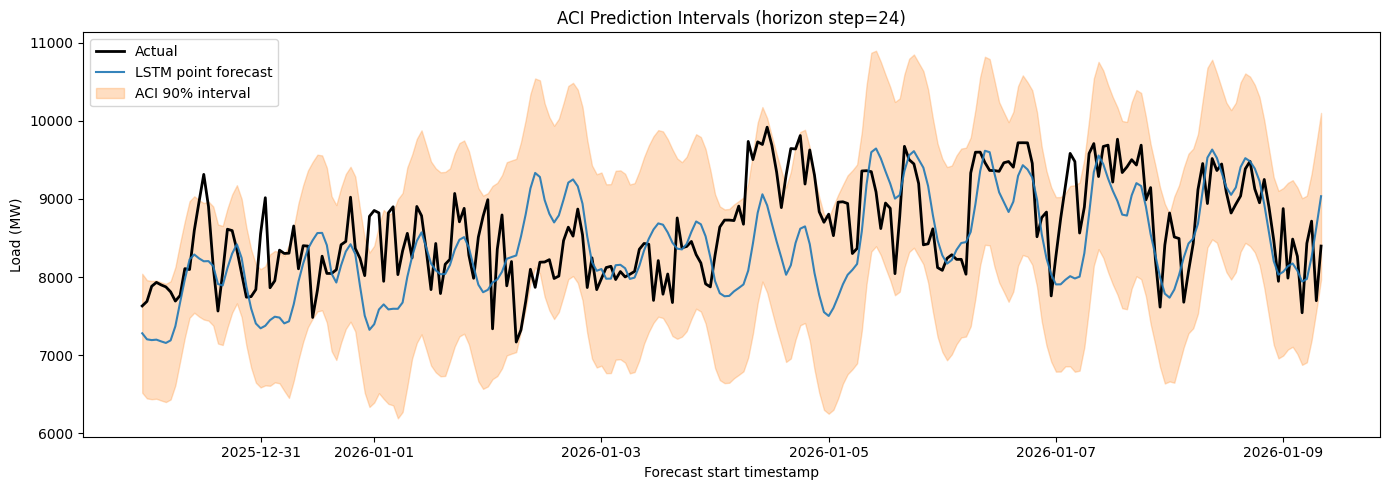

In [88]:
# Plot ACI prediction intervals for the chosen horizon step.
test_idx_for_windows = test_df.index[LOOKBACK: len(test_df) - HORIZON + 1]
plot_n = min(250, len(test_idx_for_windows))

plt.figure(figsize=(14, 5))
plt.plot(test_idx_for_windows[:plot_n], y_eval[:plot_n], label="Actual", linewidth=2, color="black")
plt.plot(test_idx_for_windows[:plot_n], aci_point[:plot_n], label="LSTM point forecast", alpha=0.9, color="tab:blue")
plt.fill_between(
    test_idx_for_windows[:plot_n],
    aci_lower[:plot_n],
    aci_upper[:plot_n],
    color="tab:orange",
    alpha=0.25,
    label=f"ACI {(1-aci_alpha):.0%} interval",
 )
plt.title(f"ACI Prediction Intervals (horizon step={aci_step + 1})")
plt.xlabel("Forecast start timestamp")
plt.ylabel("Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()

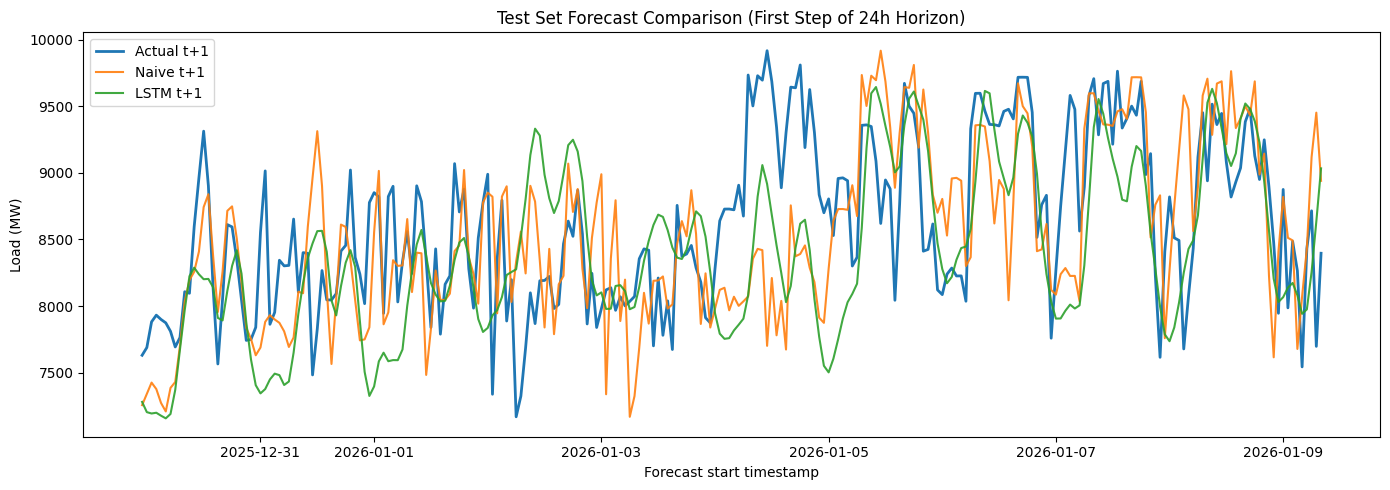

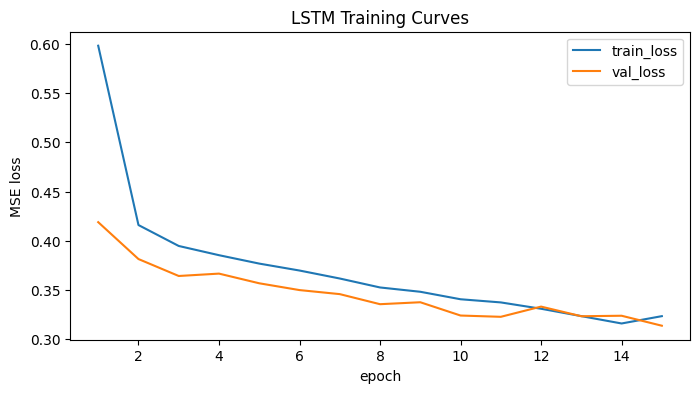

,hour_ahead,naive_mae,lstm_mae
0,1,362.541351,367.944427
1,2,464.628326,405.222809
2,3,544.603333,425.092377
3,4,598.879211,442.959137
4,5,660.884277,446.920319
5,6,698.200317,446.380432
6,7,730.137146,444.942505
7,8,744.538086,430.282715
8,9,750.403442,443.294891
9,10,754.584351,434.085510


In [89]:
test_idx_for_windows = test_df.index[LOOKBACK: len(test_df) - HORIZON + 1]

# Plot only the first forecast step (t+1) for readability.
actual_step1 = y_test_true[:,23]
naive_step1 = y_test_pred_naive[:, 23]
lstm_step1 = y_test_pred_lstm[:, 23]

plot_n = min(250, len(test_idx_for_windows))

plt.figure(figsize=(14, 5))
plt.plot(test_idx_for_windows[:plot_n], actual_step1[:plot_n], label="Actual t+1", linewidth=2)
plt.plot(test_idx_for_windows[:plot_n], naive_step1[:plot_n], label="Naive t+1", alpha=0.9)
plt.plot(test_idx_for_windows[:plot_n], lstm_step1[:plot_n], label="LSTM t+1", alpha=0.9)
plt.title("Test Set Forecast Comparison (First Step of 24h Horizon)")
plt.xlabel("Forecast start timestamp")
plt.ylabel("Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()

history_df.plot(x="epoch", y=["train_loss", "val_loss"], figsize=(8, 4), title="LSTM Training Curves")
plt.ylabel("MSE loss")
plt.show()

horizon_mae = pd.DataFrame(
    {
        "hour_ahead": np.arange(1, HORIZON + 1),
        "naive_mae": np.mean(np.abs(y_test_true - y_test_pred_naive), axis=0),
        "lstm_mae": np.mean(np.abs(y_test_true - y_test_pred_lstm), axis=0),
    }
)
horizon_mae

In [87]:
model_out_dir = PROJECT_ROOT / "data" / "processed" / "models"
model_out_dir.mkdir(parents=True, exist_ok=True)
model_out_path = model_out_dir / "best_lstm_24h.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "feature_cols": feature_cols,
        "lookback": LOOKBACK,
        "horizon": HORIZON,
        "target_col": TARGET_COL,
        "x_scaler_mean": x_scaler.mean_,
        "x_scaler_scale": x_scaler.scale_,
        "y_scaler_mean": y_scaler.mean_,
        "y_scaler_scale": y_scaler.scale_,
    },
    model_out_path,
 )

print("Saved LSTM model to:", model_out_path)
print(compare_df)

Saved LSTM model to: /home/alvard/projects/load_forecasting/data/processed/models/best_lstm_24h.pt
                  model         mae        rmse
1              lstm_24h  430.856873  547.541637
0  naive_last_value_24h  676.550049  862.018851
